In [3]:
import numpy as np

In [4]:
from gaussian_systems.initial_state import GaussianCVState

In [26]:
n = 2 # system size
kappa = 1 # normalized decay rate
n_mode_state = GaussianCVState.vacuum(2)
base_state = n_mode_state.copy_state().two_mode_squeeze((0.45, 0.0),(1,2))

In [27]:
from gaussian_systems.systems import GaussianCVSystem

In [32]:
mode_frequencies = np.array([2.0*kappa,2.0*kappa]) # mode frequencies are 2*kappa
n_bar_zero = 0 # zero temperature environment
n_mode_free_system = GaussianCVSystem.free_evolution(n, mode_frequencies)

base_system = n_mode_free_system.copy_system().multi_thermal_dissipator(
    subsystem=(1,),
    decay=kappa,
    thermal_occupation=n_bar_zero
)

base_system.multi_thermal_dissipator(
    subsystem=(2,),
    decay=kappa,
    thermal_occupation=n_bar_zero
)

In [33]:
t_eval = np.linspace(0,10,1000)

base_solution = base_system.evolve_state(base_state,t_eval)

In [34]:
base_entanglement = base_solution.entanglement_time_trace((1,2))
base_purity = base_solution.purity_time_trace((1,2))

In [42]:
n_bar_thermal = 0.5 # finite temperature environment
thermal_system = n_mode_free_system.copy_system().multi_thermal_dissipator(
    subsystem=(1,),
    decay=kappa,
    thermal_occupation=n_bar_thermal
)

thermal_system.multi_thermal_dissipator(
    subsystem=(2,),
    decay=kappa,
    thermal_occupation=n_bar_thermal
)

In [44]:
thermal_solution = thermal_system.evolve_state(base_state,t_eval)

thermal_entanglement = thermal_solution.entanglement_time_trace((1,2))
thermal_purity = thermal_solution.purity_time_trace((1,2))

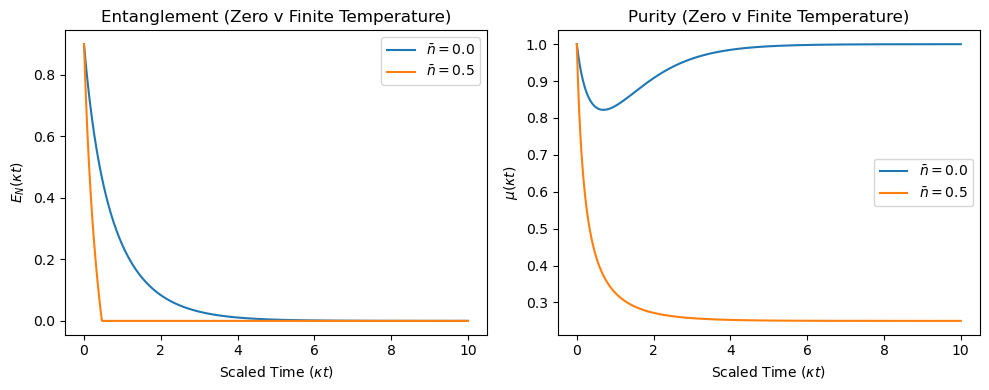

In [52]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(t_eval, base_entanglement, label=r"$\bar{n} = 0.0$")
axes[0].plot(t_eval, thermal_entanglement, label=r"$\bar{n} = 0.5$")
axes[0].set_title("Entanglement (Zero v Finite Temperature)")
axes[0].set_ylabel(r"$E_N(\kappa t)$")
axes[1].plot(t_eval, base_purity, label=r"$\bar{n} = 0.0$")
axes[1].plot(t_eval, thermal_purity, label=r"$\bar{n} = 0.5$")
axes[1].set_title("Purity (Zero v Finite Temperature)")
axes[1].set_ylabel(r"$\mu(\kappa t)$")
for ax in axes:
    ax.set_xlabel(r"Scaled Time $(\kappa t)$")
    ax.legend()
plt.tight_layout()
plt.show()